<a href="https://colab.research.google.com/github/Cooljoe67/ML_DSAI/blob/main/UML_Day_3_Warmup__Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Run this but don't look at this !

In [ ]:
# @title
# Setup the data
import pandas as pd

# Load real data
# ID of the Google Sheet for student food preferences
sheet_id = "1pBjQzLm1zdsbH_zr099nNkC1rLQmzUrN"

# Title of the Google Sheet
sheet_name = "1937353490"

# URL to download the Google Sheet as a CSV
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_name}"

# Create a Pandas DataFrame from the CSV data
foods_df = pd.read_csv(url, index_col="student")

# Drop columns not usefull
foods_df = foods_df.drop(columns=["age","favorite_color"])

# Generate fake data and define plotting functions

from sklearn.datasets import make_blobs


centers = [
    (1, 1, 8, 2, 8, 3, 2, 4, 600),
    (5, 3, 4, 1, 7, 4, 6, 8, 900),
    (6, 3, 9, 5, 8, 6, 7, 7, 400),
    (2, 6, 7, 3, 5, 2, 8, 5, 30),
    (7, 8, 2, 6, 3, 9, 5, 2, 800)
]
X, y = make_blobs(n_samples=80, centers=centers, cluster_std=2, random_state=42)

# Create a new DataFrame with all rows from X and the same columns as foods_df
fake_df = pd.DataFrame(X, columns=foods_df.columns)


easy_X, easy_y = make_blobs(n_samples=80, centers=centers, cluster_std=.5, random_state=42)

easy_df = pd.DataFrame(easy_X, columns=foods_df.columns)

#### The data for this warmup is called fake_df

In [ ]:
# @title
# A small explorative plotting function

import random
import matplotlib.pyplot as plt

def rand_plot_2d(df):
    c1, c2 = random.randint(0, len(df.columns)-1), random.randint(0, len(df.columns)-1)
    plt.scatter(x=df.iloc[:, c1], y=df.iloc[:, c2])
    plt.xlabel(df.columns[c1])
    plt.ylabel(df.columns[c2])
    plt.show()

Here I prepared a random plot that picks two random dimensions and plots the data in a scatterplot. Do you see any clusters?

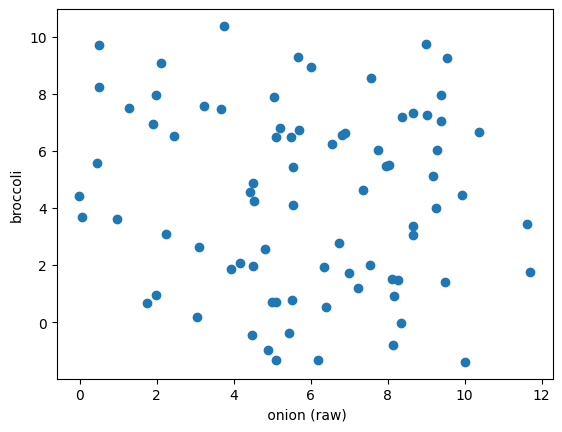

In [ ]:
rand_plot_2d(fake_df)

####Exercise 1: Import a scaler and initialize it

In [ ]:
# Your code here

#####Hint:

Google "sklearn" + the scaler you want to use to find the scaler's documentation<br>
At the very top it says `class sklearn.______.______(`... This is kind of like a file path telling us where to find the model in the library. So to import it we run `from sklearn.______ import ______`.<br><br>
To initialize the scaler we call it like a function and assign the result to a variable: `scaler = ______()`

####Exercise 2: Scale fake df using your scaler

In [ ]:
# Your code here

#####Hint:

`.fit_transform(data)`

####Exercise 3: Initialize a K-means model and fit it to the scaled data

In [ ]:
# Your code here

#####Hint:

Google "sklearn kmeans" to find the documentation so you can see where to import it from
```
from sklearn._________ import Kmeans
model = _________(n_clusters=____)
model.fit(data)
```

####Exercise 4: Extract the labels from the fit model, add them to the original data frame, and sort it by the cluster assignments to more easily see the groupings

In [ ]:
# Your code here

#####Hint:

`foods_df['cluster'] = model.________`<br>
Check [the attributes section of the KMeans documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#:~:text=instead%20of%20%E2%80%9Celkan%E2%80%9D.-,Attributes%3A,-cluster_centers_ndarray%20of) to see where you can get the model's labels<br><br>
`df.sort_values()`

#### Bonus: Compare scaled cluster labels versus unscaled cluster labels

In [ ]:
# Your code here

#####Hint:

Iterate the above but without scaling the data.